# Which Campaigns are Actually Worth the Spend?

### 1. Load the dataset.
Then check the basics:
- dimensionality (rows, columns)
- column names, datatypes, and number of non-null values
- descriptive statistics (for numerical columns)
- are there any missing values?

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/super-unknowledge/campaign-analysis-1/refs/heads/main/synthetic_social_media_campaign_data.csv"
df = pd.read_csv(url)

df.head()

,campaign_id,campaign_name,platform,post_type,post_date,post_time,content_theme,target_audience,boosted_post,spend_usd,...,conversions,conversion_value_usd,cpc_usd,ctr,engagement_rate,hashtag_count,emoji_count,word_count,sentiment_score,video_length_seconds
0,CMP1000,Summer Campaign 2025,TikTok,Story,1/8/2024,13:45,Promotion,"Gen Z (18-24, Urban)",False,8.46,...,25,503.43,0.05,0.0297,0.0883,9,2,18,0.12,37
1,CMP1000,Back to School Campaign 2024,X,Video,1/3/2024,19:30,Behind-the-Scenes,"Parents (30-45, Suburban)",True,7.07,...,5,249.50,0.14,0.0098,0.0320,2,0,12,-0.16,22
2,CMP1000,Spring Campaign 2025,LinkedIn,Story,1/20/2024,9:30,User Testimonial,"Gen Z (18-24, Urban)",True,40.60,...,56,2138.28,0.11,0.0300,0.1152,13,5,16,0.30,113
3,CMP1000,Summer Campaign 2024,Facebook,Image,1/14/2024,11:00,User Testimonial,"Gen X (35-50, Mixed)",True,5.23,...,19,1360.52,0.03,0.0553,0.1167,1,9,45,-0.39,0
4,CMP1000,Spring Campaign 2025,Instagram,Video,1/4/2024,11:00,Behind-the-Scenes,"Millennials (25-34, Suburban)",False,5.38,...,10,1312.49,0.07,0.0244,0.0694,13,2,40,-0.11,119


In [2]:
df.shape

(1610, 24)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   campaign_id           1610 non-null   object 
 1   campaign_name         1610 non-null   object 
 2   platform              1610 non-null   object 
 3   post_type             1610 non-null   object 
 4   post_date             1610 non-null   object 
 5   post_time             1610 non-null   object 
 6   content_theme         1610 non-null   object 
 7   target_audience       1610 non-null   object 
 8   boosted_post          1610 non-null   bool   
 9   spend_usd             1610 non-null   float64
 10  reach                 1610 non-null   int64  
 11  impressions           1610 non-null   int64  
 12  engagements           1610 non-null   int64  
 13  clicks                1610 non-null   int64  
 14  conversions           1610 non-null   int64  
 15  conversion_value_usd 

In [4]:
df.describe()

,spend_usd,reach,impressions,engagements,clicks,conversions,conversion_value_usd,cpc_usd,ctr,engagement_rate,hashtag_count,emoji_count,word_count,sentiment_score,video_length_seconds
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,37.921410,5677.191925,7577.076398,397.242857,198.421118,24.656522,1947.463789,0.242106,0.025947,0.069577,7.454037,5.114907,27.573292,0.183379,38.767702
std,49.690521,3542.976873,4596.120964,315.775973,167.967635,24.441697,2435.286218,0.327396,0.013041,0.028743,4.549370,3.174023,13.118617,0.464015,40.813124
min,0.010000,166.000000,259.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.003400,0.019100,0.000000,0.000000,5.000000,-1.000000,0.000000
25%,4.962500,3226.250000,4328.750000,171.000000,80.000000,9.000000,471.580000,0.040000,0.015600,0.044600,3.000000,2.000000,16.000000,-0.140000,0.000000
50%,17.355000,5247.000000,7106.000000,326.000000,156.000000,18.000000,1123.225000,0.140000,0.024000,0.068700,7.500000,5.000000,27.000000,0.190000,24.000000
75%,52.972500,7428.750000,9823.750000,542.000000,267.750000,33.000000,2494.772500,0.320000,0.034275,0.094100,11.000000,8.000000,39.000000,0.510000,75.000000
max,425.390000,28457.000000,33893.000000,2684.000000,1337.000000,220.000000,21624.050000,3.650000,0.069900,0.119900,15.000000,10.000000,50.000000,1.000000,120.000000


In [5]:
print(df.isnull().sum())

campaign_id             0
campaign_name           0
platform                0
post_type               0
post_date               0
post_time               0
content_theme           0
target_audience         0
boosted_post            0
spend_usd               0
reach                   0
impressions             0
engagements             0
clicks                  0
conversions             0
conversion_value_usd    0
cpc_usd                 0
ctr                     0
engagement_rate         0
hashtag_count           0
emoji_count             0
word_count              0
sentiment_score         0
video_length_seconds    0
dtype: int64


Let's peek at the unique values of some of the columns we'll use later:

In [6]:
# Check unique values for platform column
# 1. Get the number of unique platforms
unique_count = df['platform'].nunique()

# 2. Get the list of all unique platforms
unique_values = df['platform'].unique()

print(unique_count, unique_values)

5 ['TikTok' 'X' 'LinkedIn' 'Facebook' 'Instagram']


In [7]:
# Check unique values for post_type column
# 1. Get the number of unique post types
unique_count = df['post_type'].nunique()

# 2. Get the list of all unique post types
unique_values = df['post_type'].unique()

print(unique_count, unique_values)

5 ['Story' 'Video' 'Image' 'Carousel' 'Reel']


In [8]:
# Check unique values for content_theme column
# 1. Get the number of unique content themes
unique_count = df['content_theme'].nunique()

# 2. Get the list of all unique content themes
unique_values = df['content_theme'].unique()

print(unique_count, unique_values)

5 ['Promotion' 'Behind-the-Scenes' 'User Testimonial' 'Product Launch'
 'Lifestyle']


Takeaways: 
- The dataset has 1,610 rows and 24 columns
- `post_date` and `post_time` are listed as "object". They'll need to be converted into datetime later. But since we're focusing on figuring out which campaigns are worth the spend, we'll leave them as is for now since they're we don't need that information.
- There are no missing values, and nothing to really clean since this is a generated dataset (Hooray!)

### 2. Perform the initial exploration.
We want to find out the following metrics:
- ROAS (Return on Ad Spend) = Conversion Value / Spend
- Cost per Conversion = Spend / Conversions
- Conversion Rate = Conversions / Clicks
- Efficiency Score = rank campaigns by ROAS within each platform

In Part 2 when we create the pipeline, we'll use postgres as our DB. SQL query versions of each line are left as comments where applicable.

In [9]:
# Only look at rows where we spend money and have conversions
# WHERE spend_usd > 0 AND conversions > 0
clean = df[(df['spend_usd'] > 0) & (df['conversions'] > 0)].copy()

# ROAS = Conversion Value / Spend
# Derived metric: Revenue per dollar spent
clean['roas'] = clean['conversion_value_usd'] / clean['spend_usd']

# Cost per Conversion = Spend / Conversions
# We know from the blog post that cpc_usd is cost per click, not conversion
# Derived metric: How much did we pay for each conversion?
clean['cost_per_conversion'] = clean['spend_usd'] / clean['conversions']

# Conversion Rate = Conversions / Clicks
# Derived metric: What percentage of the people who clicked get converted?
clean['conversion_rate'] = clean['conversions'] / clean['clicks']

# Efficiency Score
# Derived metric: Which campaigns have the best return per platform?
# Rank by ROAS within each Platform (Highest ROAS gets Rank 1)
clean['efficiency_rank'] = clean.groupby('platform')['roas'].rank(ascending=False, method='min')

In [15]:
# Assuming we sorted the final DataFrame for clear reading:
df_sorted = clean.sort_values(by=['platform', 'efficiency_rank'])
print(df_sorted[['platform', 'campaign_name', 'roas', 'efficiency_rank']])

      platform                 campaign_name          roas  efficiency_rank
154   Facebook         Holiday Campaign 2024  28878.090909              1.0
231   Facebook         Holiday Campaign 2025  11071.428571              2.0
1533  Facebook            Fall Campaign 2024  10996.256410              3.0
1057  Facebook  Back to School Campaign 2025  10393.140845              4.0
485   Facebook  Back to School Campaign 2024   6438.107143              5.0
...        ...                           ...           ...              ...
498          X            Fall Campaign 2024      1.983679            347.0
292          X         Holiday Campaign 2025      1.809534            348.0
803          X          Summer Campaign 2025      1.708699            349.0
672          X          Spring Campaign 2025      1.647573            350.0
282          X          Summer Campaign 2025      1.501852            351.0

[1584 rows x 4 columns]


### 3. Perform A/B testing.
The dataset has multiple Post Types (Image, Video, Carousel, Story). 

So let's answer the question: "Do video posts actually convert better than image posts, or does it just look that way?"

We can do an A/B test by running a two-sample t-test on conversion rates between post types:

In [34]:
from scipy import stats

video = clean[clean['post_type'] == 'Video']['conversion_rate']
image = clean[clean['post_type'] == 'Image']['conversion_rate']

t_stat, p_value = stats.ttest_ind(video, image)
print(video.count())
print(image.count())
print(f"p-value: {p_value:.4f}")
print("Statistically significant!" if p_value < 0.05 else "No significant difference — could be noise")

326
305
p-value: 0.3002
No significant difference — could be noise


We cannot confidently say video outperforms image on this platform. The difference could be random variation with this sample size.

Let's try answering: "Do Instagram posts convert better than posts on X?"

In [35]:
ig = clean[clean['platform'] == 'Instagram']['conversion_rate']
x = clean[clean['platform'] == 'X']['conversion_rate']

t_stat, p_value = stats.ttest_ind(ig, x)
print(ig.count())
print(x.count())
print(f"p-value: {p_value:.4f}")
print("Statistically significant!" if p_value < 0.05 else "No significant difference — could be noise")

321
351
p-value: 0.0246
Statistically significant!


So, we can say that our posts on Instagram convert than our posts on X. That makes sense intuitively.

### 4. Gain insights from charts.

We'll explore three questions and generate a chart for each one.

Chart 1 — Platform efficiency scatter plot: Which platforms give the best return per dollar?

*(X = average CPC, Y = average ROAS, bubble size = total Spend.)*

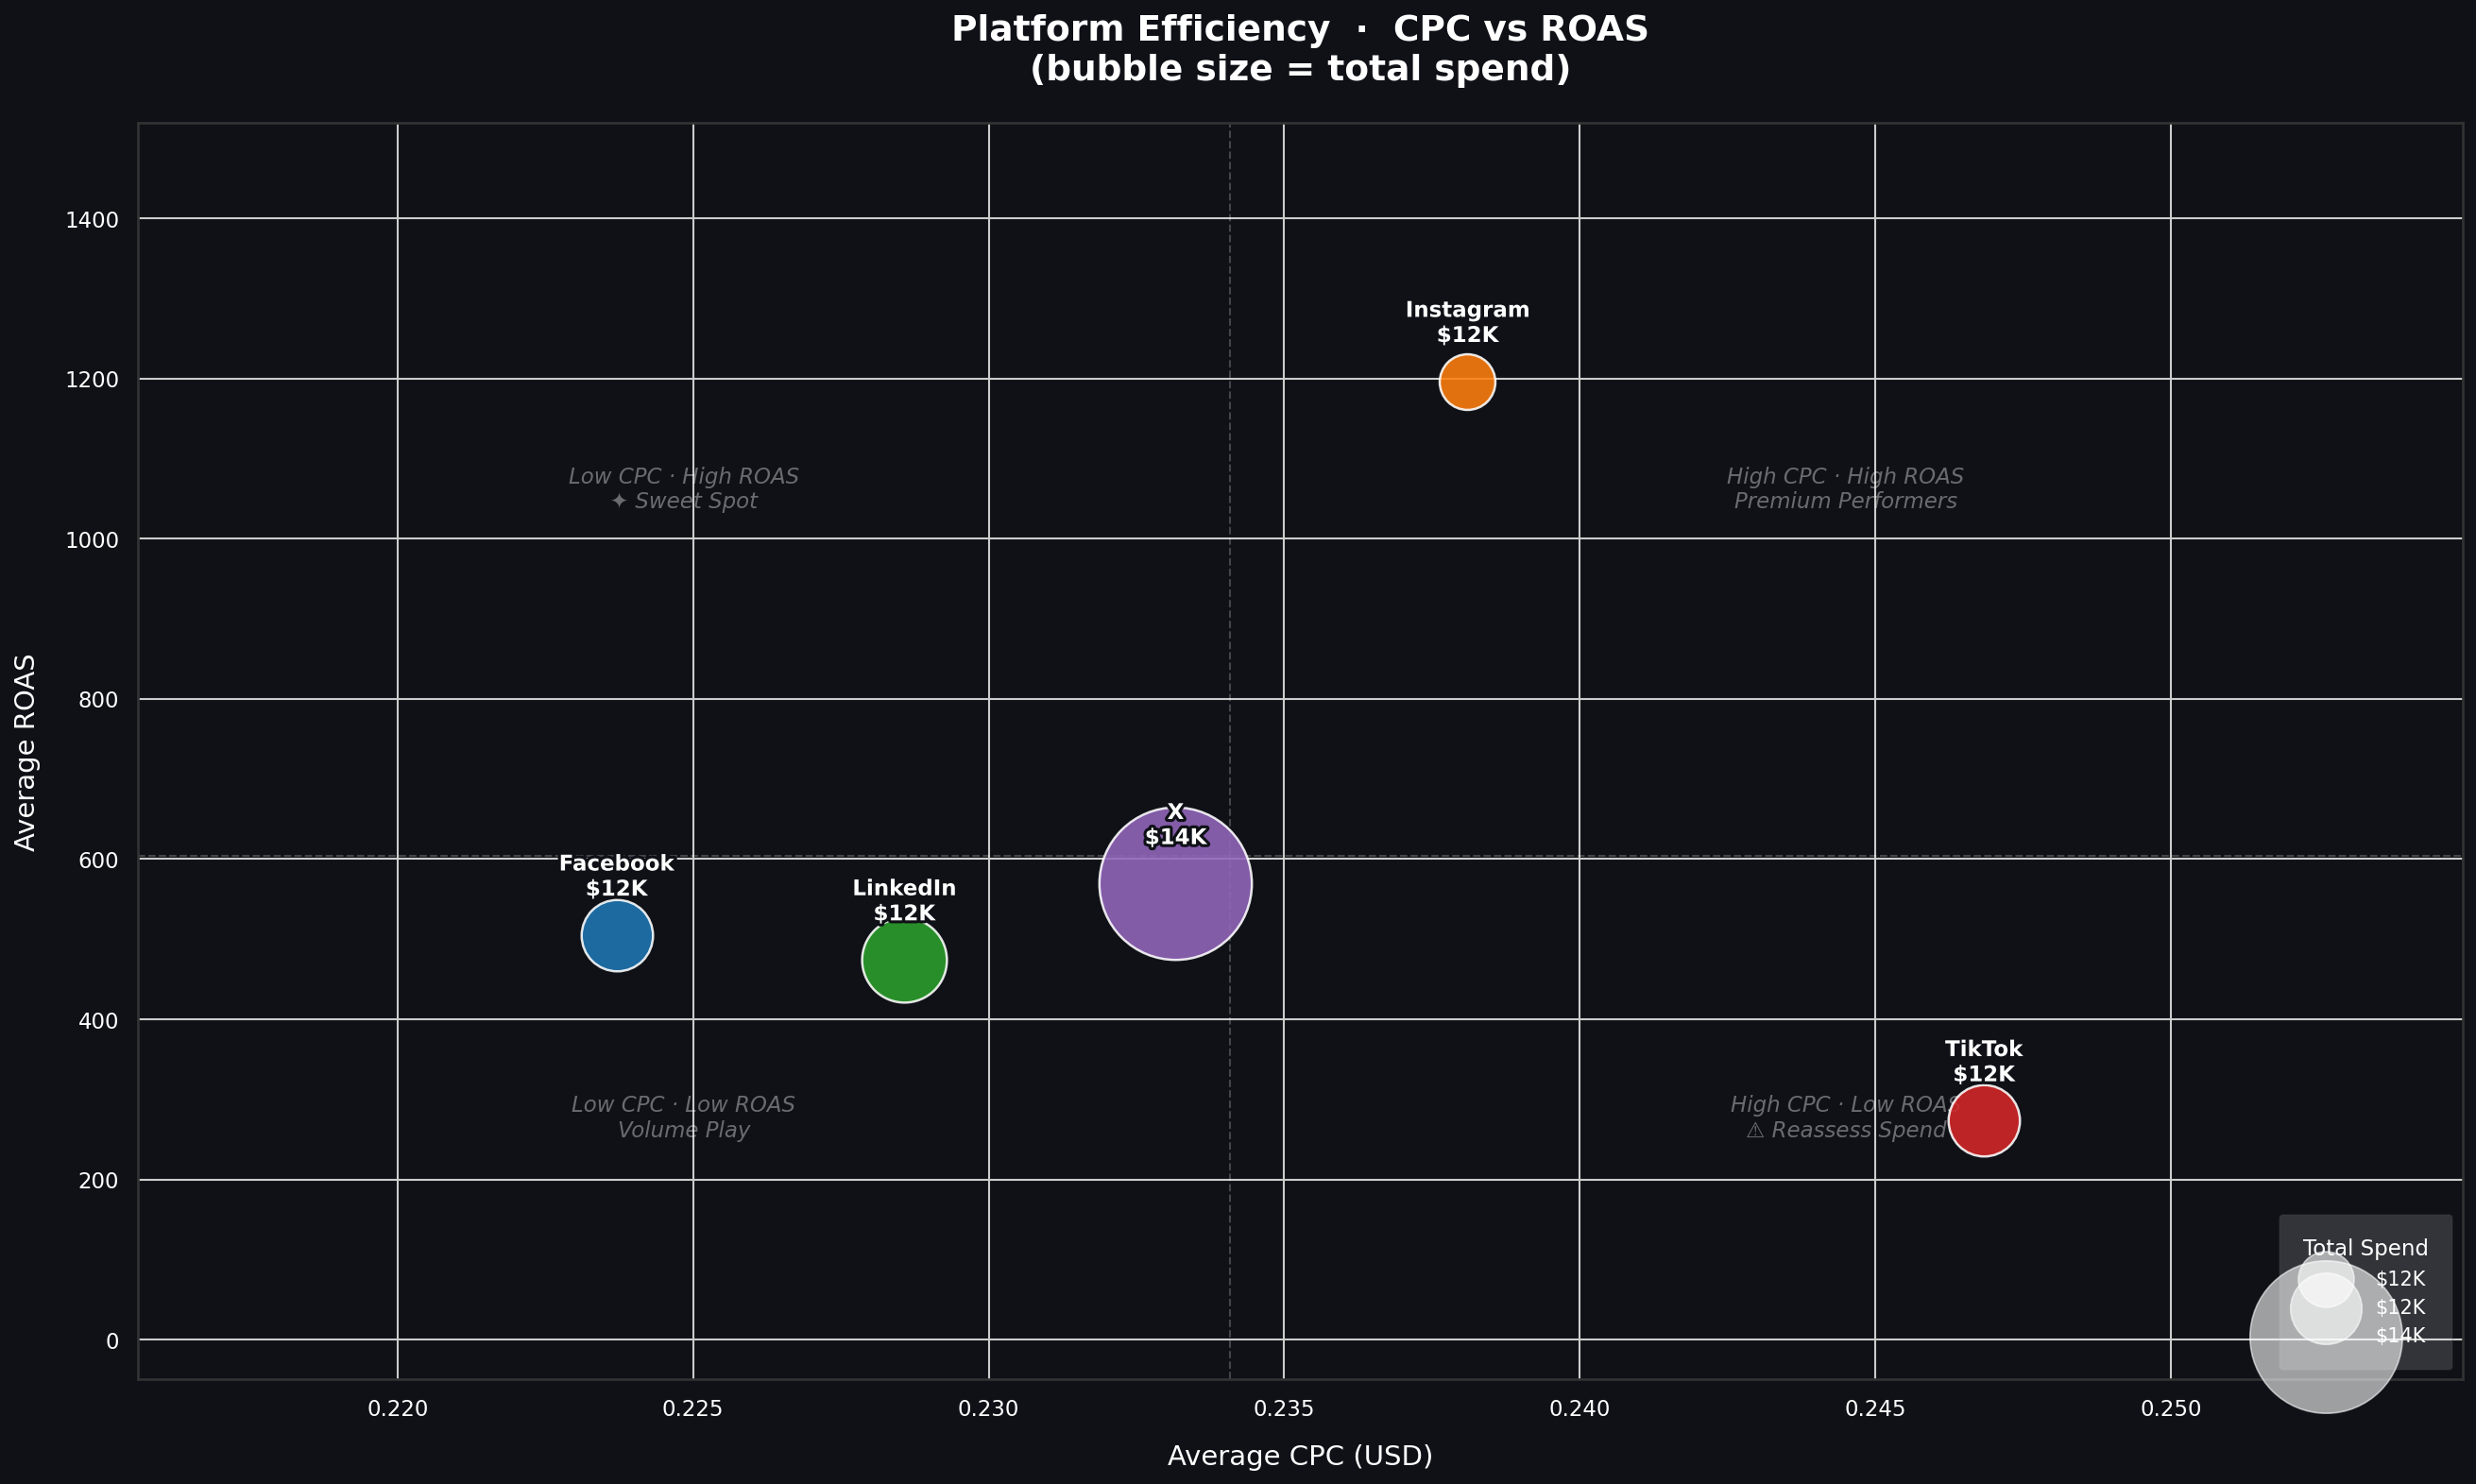

✅ Chart saved as platform_efficiency.png


In [38]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

# ── Force Colab to render at full width ────────────────────────────────────
plt.rcParams["figure.dpi"]     = 150
plt.rcParams["figure.figsize"] = (18, 11)
plt.rcParams["font.size"]      = 13

# ── Aggregation (if your raw data has multiple rows per platform) ───────────
agg = clean.groupby("platform").agg(
    avg_cpc     = ("cpc_usd",   "mean"),
    avg_roas    = ("roas",      "mean"),
    total_spend = ("spend_usd", "sum"),
).reset_index()

# ── Palette ────────────────────────────────────────────────────────────────
palette = sns.color_palette("tab10", n_colors=len(agg))

# ── Bubble sizing ──────────────────────────────────────────────────────────
min_size, max_size = 800, 6000
spend_norm   = (agg["total_spend"] - agg["total_spend"].min()) / \
               (agg["total_spend"].max() - agg["total_spend"].min())
bubble_sizes = min_size + spend_norm * (max_size - min_size)

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 11))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# ── Axis padding so bubbles/labels don't clip ──────────────────────────────
x_pad = (agg["avg_cpc"].max()  - agg["avg_cpc"].min())  * 0.35
y_pad = (agg["avg_roas"].max() - agg["avg_roas"].min()) * 0.35
ax.set_xlim(agg["avg_cpc"].min()  - x_pad, agg["avg_cpc"].max()  + x_pad)
ax.set_ylim(agg["avg_roas"].min() - y_pad, agg["avg_roas"].max() + y_pad)

# ── Reference crosshairs ───────────────────────────────────────────────────
avg_cpc_line  = agg["avg_cpc"].mean()
avg_roas_line = agg["avg_roas"].mean()

ax.axvline(avg_cpc_line,  color="#ffffff", linewidth=1.0, linestyle="--", alpha=0.22)
ax.axhline(avg_roas_line, color="#ffffff", linewidth=1.0, linestyle="--", alpha=0.22)

# ── Quadrant labels ────────────────────────────────────────────────────────
xlim = ax.get_xlim()
ylim = ax.get_ylim()

quad_kw = dict(fontsize=11, alpha=0.38, color="white", fontstyle="italic")
mid_left  = (xlim[0] + avg_cpc_line)  / 2
mid_right = (avg_cpc_line + xlim[1])  / 2
mid_top   = (avg_roas_line + ylim[1]) / 2
mid_bot   = (ylim[0] + avg_roas_line) / 2

ax.text(mid_left,  mid_top, "Low CPC · High ROAS\n✦ Sweet Spot",       **quad_kw, ha="center", va="center")
ax.text(mid_right, mid_top, "High CPC · High ROAS\nPremium Performers", **quad_kw, ha="center", va="center")
ax.text(mid_left,  mid_bot, "Low CPC · Low ROAS\nVolume Play",          **quad_kw, ha="center", va="center")
ax.text(mid_right, mid_bot, "High CPC · Low ROAS\n⚠ Reassess Spend",   **quad_kw, ha="center", va="center")

# ── Bubbles ────────────────────────────────────────────────────────────────
for i, row in agg.iterrows():
    ax.scatter(
        row["avg_cpc"], row["avg_roas"],
        s=bubble_sizes[i],
        color=palette[i],
        alpha=0.88,
        edgecolors="white",
        linewidths=1.2,
        zorder=3,
    )

# ── Labels on bubbles ──────────────────────────────────────────────────────
for i, row in agg.iterrows():
    spend_fmt = f"${row['total_spend']/1000:.0f}K"
    label     = f"{row['platform']}\n{spend_fmt}"
    ax.annotate(
        label,
        xy=(row["avg_cpc"], row["avg_roas"]),
        xytext=(0, 20),
        textcoords="offset points",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        path_effects=[pe.withStroke(linewidth=3, foreground="#0f1117")],
        zorder=4,
    )

# ── Axes styling ───────────────────────────────────────────────────────────
ax.set_xlabel("Average CPC (USD)", fontsize=14, color="white", labelpad=12)
ax.set_ylabel("Average ROAS",      fontsize=14, color="white", labelpad=12)
ax.set_title(
    "Platform Efficiency  ·  CPC vs ROAS\n(bubble size = total spend)",
    fontsize=18, fontweight="bold", color="white", pad=22,
)

ax.tick_params(colors="white", labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

# ── Bubble size legend ─────────────────────────────────────────────────────
legend_spends = [agg["total_spend"].min(), agg["total_spend"].median(), agg["total_spend"].max()]
legend_sizes  = [
    min_size + ((s - agg["total_spend"].min()) /
                (agg["total_spend"].max() - agg["total_spend"].min())) * (max_size - min_size)
    for s in legend_spends
]

legend_handles = [
    plt.scatter([], [], s=sz, color="white", alpha=0.6, edgecolors="white",
                linewidths=0.8, label=f"${sp/1000:.0f}K")
    for sz, sp in zip(legend_sizes, legend_spends)
]
legend = ax.legend(
    handles=legend_handles,
    title="Total Spend",
    title_fontsize=11,
    fontsize=10,
    labelcolor="white",
    loc="lower right",
    framealpha=0.15,
    edgecolor="#555555",
    borderpad=1.2,
    handletextpad=1.5,
)
legend.get_title().set_color("white")

plt.tight_layout(pad=2.0)
plt.savefig("platform_efficiency.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Chart saved as platform_efficiency.png")

Chart 2 — Content Theme performance bar chart: What is the Average Conversion Rate by Content Theme? 

We show ±1 standard deviation with the error bars to see the variance.

*(X = Average Conversion Rate, Grouped by Content Theme)*

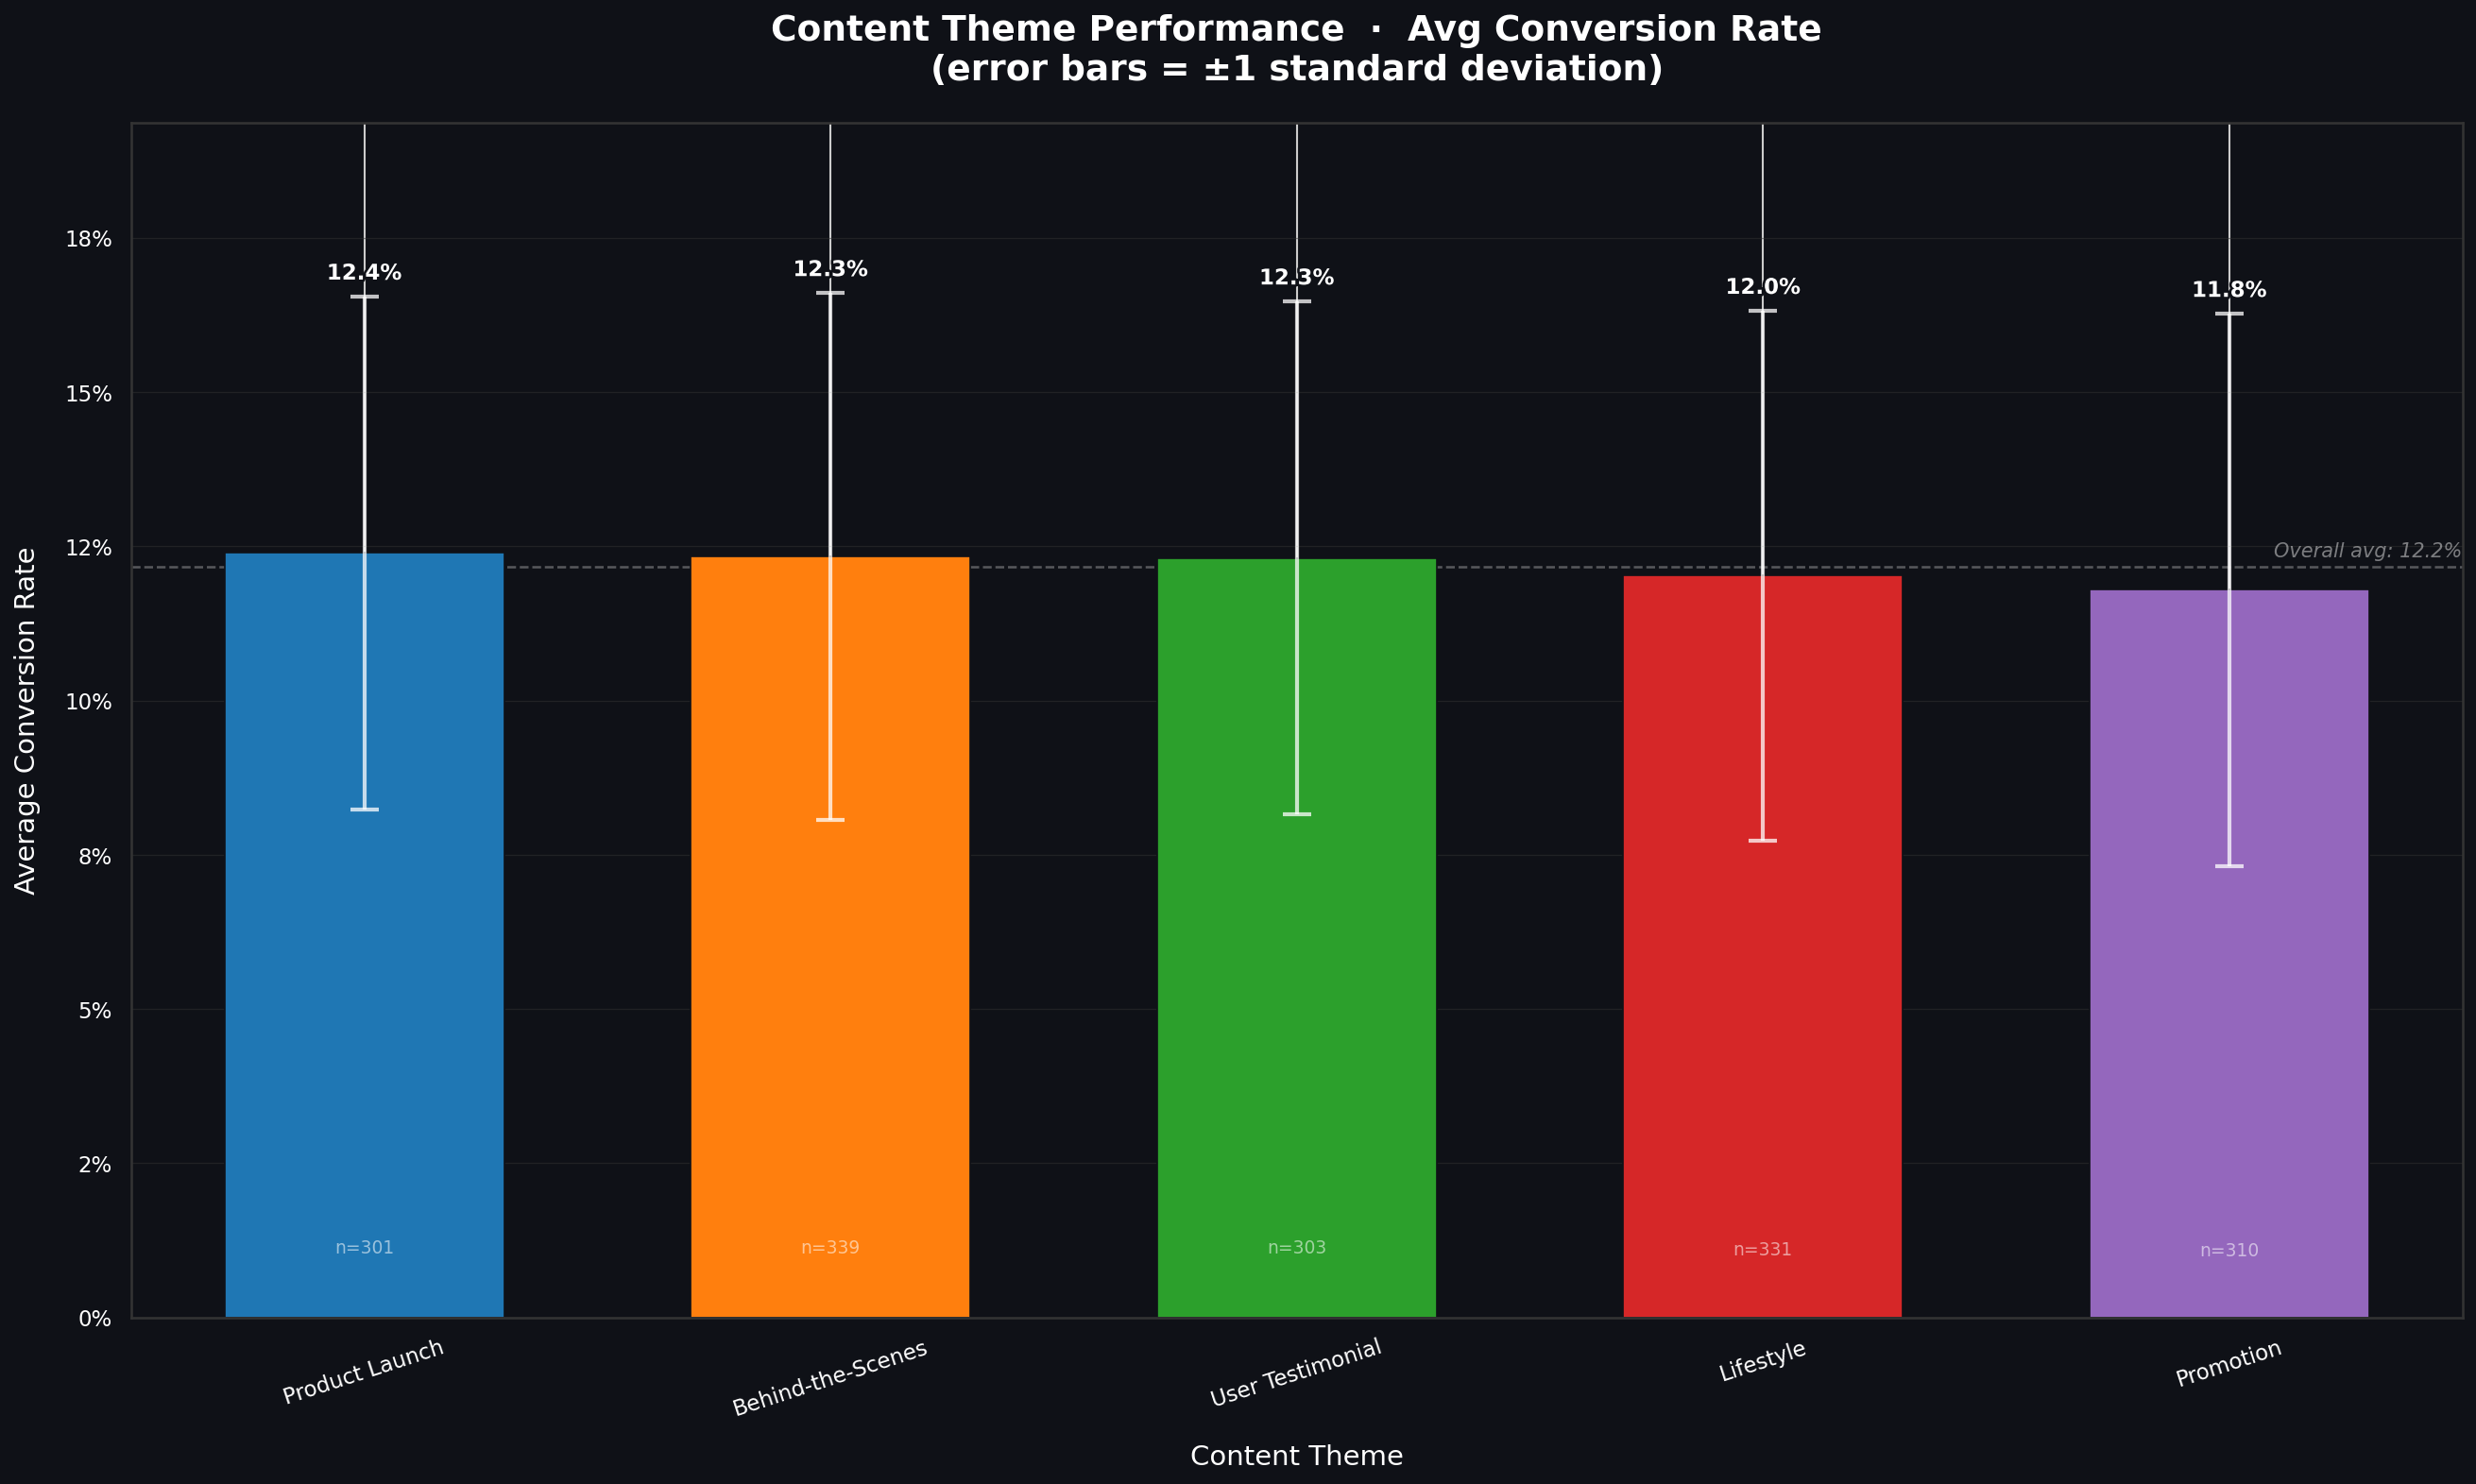

In [39]:
# ── Aggregate ──────────────────────────────────────────────────────────────
agg = (
    clean.groupby("content_theme")["conversion_rate"]
    .agg(avg_cr="mean", std_cr="std", n="count")
    .reset_index()
    .sort_values("avg_cr", ascending=False)
    .reset_index(drop=True)
)

# ── Palette (tab10 — same as Chart 1) ─────────────────────────────────────
palette = sns.color_palette("tab10", n_colors=len(agg))

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 11))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# ── Bars ───────────────────────────────────────────────────────────────────
bars = ax.bar(
    agg["content_theme"],
    agg["avg_cr"],
    color=palette,
    width=0.6,
    zorder=2,
    edgecolor="#0f1117",
    linewidth=0.8,
)

# ── Error bars (std dev) ───────────────────────────────────────────────────
ax.errorbar(
    x=agg["content_theme"],
    y=agg["avg_cr"],
    yerr=agg["std_cr"],
    fmt="none",
    color="white",
    capsize=7,
    capthick=2.0,
    elinewidth=2.0,
    alpha=0.75,
    zorder=3,
)

# ── Value labels above each bar ────────────────────────────────────────────
for i, row in agg.iterrows():
    top = row["avg_cr"] + row["std_cr"]          # label clears the error bar cap
    ax.text(
        i, top + 0.002,
        f"{row['avg_cr']*100:.1f}%",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color="white",
        path_effects=[pe.withStroke(linewidth=2.5, foreground="#0f1117")],
        zorder=4,
    )

# ── Sample size annotation inside/below bar ────────────────────────────────
for i, row in agg.iterrows():
    ax.text(
        i, row["avg_cr"] * 0.08,
        f"n={row['n']}",
        ha="center", va="bottom",
        fontsize=9, color="white", alpha=0.55,
        zorder=4,
    )

# ── Average reference line ─────────────────────────────────────────────────
overall_avg = clean["conversion_rate"].mean()
ax.axhline(overall_avg, color="white", linewidth=1.2, linestyle="--", alpha=0.30, zorder=1)
ax.text(
    len(agg) - 0.5, overall_avg + 0.001,
    f"Overall avg: {overall_avg*100:.1f}%",
    ha="right", va="bottom", fontsize=10, color="white", alpha=0.45,
    fontstyle="italic",
)

# ── Y-axis as percentage ───────────────────────────────────────────────────
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

# ── Axes styling ───────────────────────────────────────────────────────────
ax.set_xlabel("Content Theme",       fontsize=14, color="white", labelpad=12)
ax.set_ylabel("Average Conversion Rate", fontsize=14, color="white", labelpad=12)
ax.set_title(
    "Content Theme Performance  ·  Avg Conversion Rate\n(error bars = ±1 standard deviation)",
    fontsize=18, fontweight="bold", color="white", pad=22,
)

ax.tick_params(axis="x", colors="white", labelsize=11, rotation=18)
ax.tick_params(axis="y", colors="white", labelsize=11)
ax.set_xlim(-0.5, len(agg) - 0.5)
ax.set_ylim(0, agg["avg_cr"].max() + agg["std_cr"].max() + 0.025)

for spine in ax.spines.values():
    spine.set_edgecolor("#333333")
ax.yaxis.grid(True, color="#333333", linewidth=0.6, alpha=0.5, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout(pad=2.0)
plt.show()

Chart 3 — Heatmap of Post Type × Platform: What is the Average ROAS for each combination? 

And which combinations of two variables produce the best outcome?

*(X = Post Type, Y = Platform)*

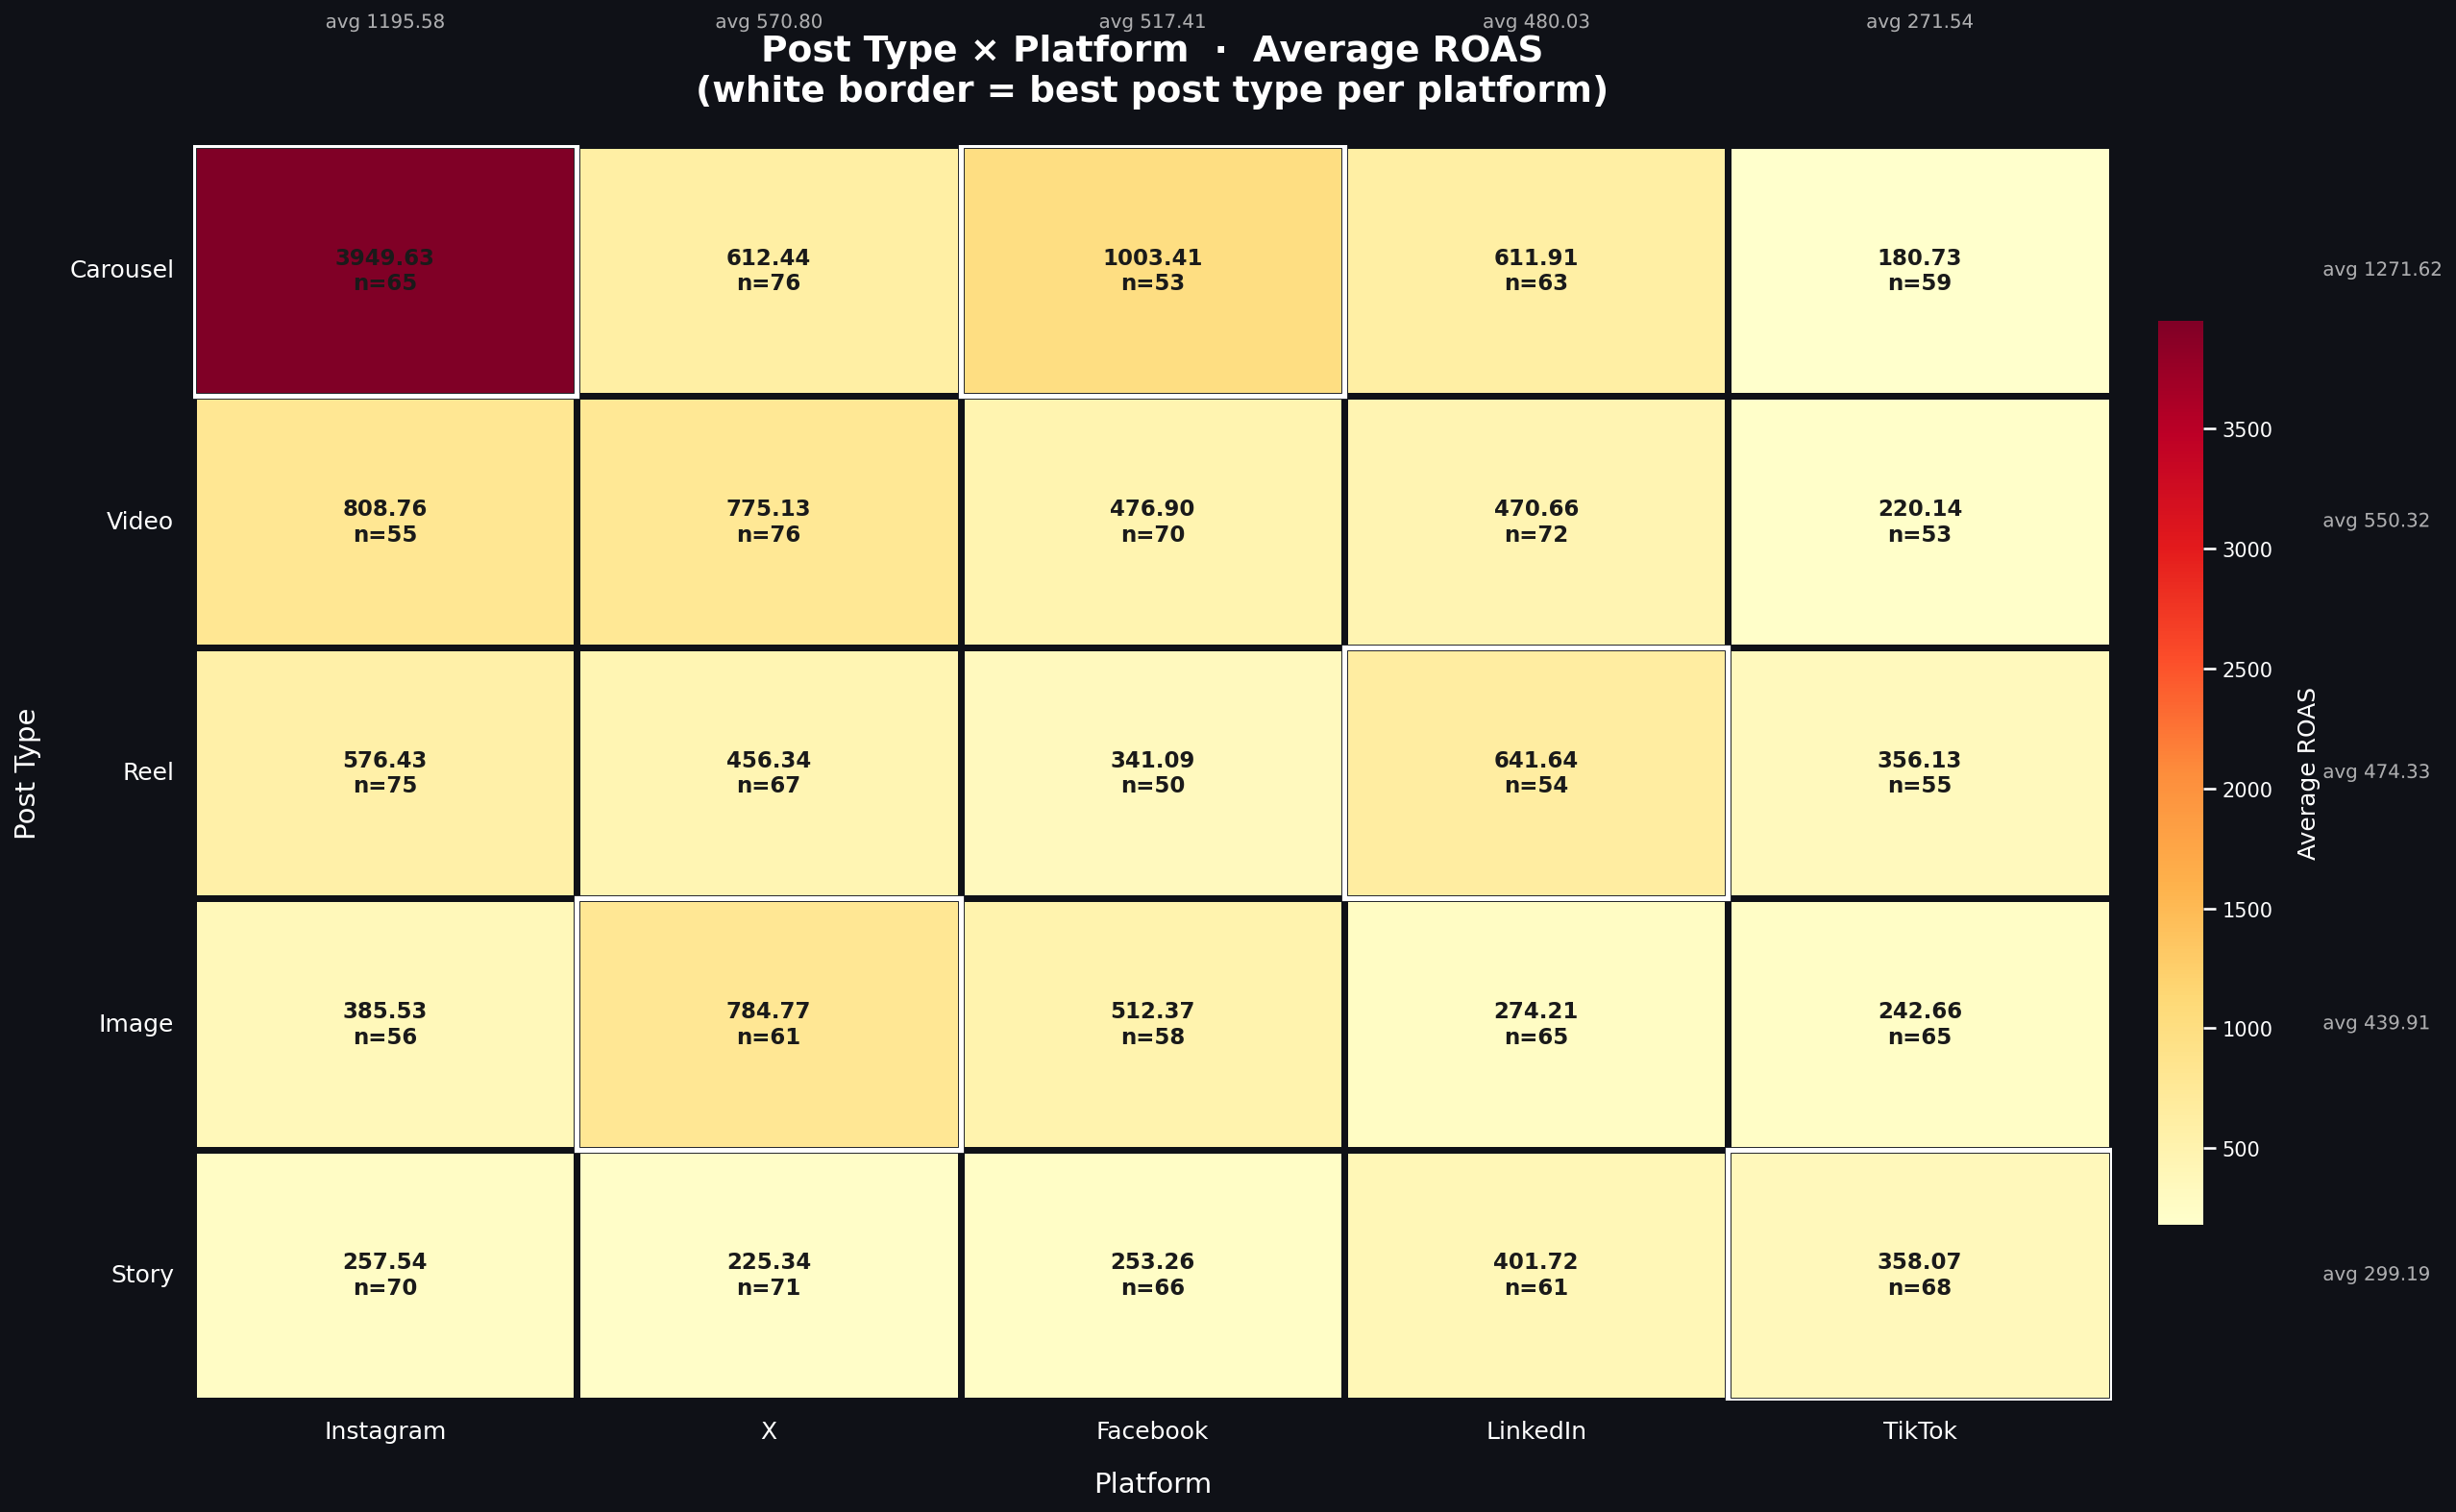

In [43]:
# ── Pivot: rows = post_type, cols = platform, values = mean roas ────────────
pivot = (
    clean.groupby(["post_type", "platform"])["roas"]
    .mean()
    .reset_index()
    .pivot(index="post_type", columns="platform", values="roas")
)

# Sort rows by overall avg ROAS descending, cols by overall avg ascending
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
pivot = pivot[pivot.mean(axis=0).sort_values(ascending=False).index]

# ── Sample-size pivot (for annotation suffix) ──────────────────────────────
counts = (
    clean.groupby(["post_type", "platform"])["roas"]
    .count()
    .reset_index()
    .pivot(index="post_type", columns="platform", values="roas")
)
counts = counts.loc[pivot.index, pivot.columns]

# ── Custom annotation: "3.42\nn=41" ───────────────────────────────────────
annot = pd.DataFrame(
    [[f"{pivot.iloc[r,c]:.2f}\nn={int(counts.iloc[r,c])}"
      for c in range(pivot.shape[1])]
     for r in range(pivot.shape[0])],
    index=pivot.index, columns=pivot.columns,
)

# ── Colormap — dark navy → rich amber/gold (cohesive with dark theme) ──────
cmap = sns.color_palette("YlOrRd", as_cmap=True)   # yellow→orange→red: bold & readable

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 11))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# ── Heatmap ────────────────────────────────────────────────────────────────
sns.heatmap(
    pivot,
    ax=ax,
    cmap=cmap,
    annot=annot,
    fmt="",                      # we supply pre-formatted strings
    annot_kws={"size": 11, "color": "#1a1a1a", "fontweight": "bold"},
    linewidths=2.5,
    linecolor="#0f1117",
    cbar_kws={"shrink": 0.72, "pad": 0.02, "label": "Average ROAS"},
)

# ── Colorbar styling ───────────────────────────────────────────────────────
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color="white", labelsize=10)
cbar.set_label("Average ROAS", color="white", fontsize=12, labelpad=12)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("#333333")

# ── Row & col averages as margin labels ────────────────────────────────────
row_avgs = pivot.mean(axis=1)
col_avgs = pivot.mean(axis=0)

for i, (idx, val) in enumerate(row_avgs.items()):
    ax.text(
        pivot.shape[1] + 0.55, i + 0.5,
        f"avg {val:.2f}",
        va="center", ha="left", fontsize=9.5,
        color="white", alpha=0.55,
        path_effects=[pe.withStroke(linewidth=1.5, foreground="#0f1117")],
    )

for j, (col, val) in enumerate(col_avgs.items()):
    ax.text(
        j + 0.5, -0.45,
        f"avg {val:.2f}",
        va="bottom", ha="center", fontsize=9.5,
        color="white", alpha=0.55,
        path_effects=[pe.withStroke(linewidth=1.5, foreground="#0f1117")],
    )

# ── Highlight best cell per column (platform) ─────────────────────────────
for j, col in enumerate(pivot.columns):
    best_row = pivot[col].idxmax()
    i = list(pivot.index).index(best_row)
    ax.add_patch(plt.Rectangle(
        (j, i), 1, 1,
        fill=False, edgecolor="white", linewidth=2.5, zorder=4,
    ))

# ── Axes styling ───────────────────────────────────────────────────────────
ax.set_xlabel("Platform",   fontsize=14, color="white", labelpad=14)
ax.set_ylabel("Post Type",  fontsize=14, color="white", labelpad=14)
ax.set_title(
    "Post Type × Platform  ·  Average ROAS\n(white border = best post type per platform)",
    fontsize=18, fontweight="bold", color="white", pad=22,
)

ax.tick_params(axis="x", colors="white", labelsize=12, rotation=0)
ax.tick_params(axis="y", colors="white", labelsize=12, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), color="white")
ax.set_yticklabels(ax.get_yticklabels(), color="white")

plt.tight_layout(pad=2.0)
plt.show()

In [ ]:
# Sanity check because I didn't think there were carousel posts on LinkedIn...
filtered_df = clean.query("post_type == 'Carousel' and platform == 'LinkedIn'")
filtered_df.head()

,campaign_id,campaign_name,platform,post_type,post_date,post_time,content_theme,target_audience,boosted_post,spend_usd,...,engagement_rate,hashtag_count,emoji_count,word_count,sentiment_score,video_length_seconds,roas,cost_per_conversion,conversion_rate,efficiency_rank
14,CMP1000,Holiday Campaign 2024,LinkedIn,Carousel,1/25/2024,19:45,Promotion,"Professionals (25-54, B2B)",True,49.83,...,0.0265,9,9,34,1.00,0,3.588401,6.228750,0.148148,311.0
28,CMP1000,Back to School Campaign 2024,LinkedIn,Carousel,1/23/2024,8:15,Product Launch,"Parents (30-45, Suburban)",True,15.27,...,0.0381,0,8,24,0.49,0,88.590046,1.527000,0.107527,136.0
31,CMP1000,Fall Campaign 2025,LinkedIn,Carousel,1/22/2024,15:45,Lifestyle,"Millennials (25-34, Suburban)",True,20.07,...,0.0334,6,4,9,0.06,0,5.976084,6.690000,0.073171,305.0
36,CMP1000,Summer Campaign 2024,LinkedIn,Carousel,1/27/2024,7:30,Product Launch,"Gen Z (18-24, Urban)",False,6.02,...,0.1113,10,10,12,1.00,0,183.166113,0.401333,0.064655,83.0
40,CMP1000,Back to School Campaign 2024,LinkedIn,Carousel,1/5/2024,15:00,Promotion,"Millennials (25-34, Suburban)",True,67.92,...,0.0685,12,2,35,0.37,0,67.251914,1.997647,0.194286,150.0


...and that's it! We're done!